# Task 1 — Character-Level GPT From Scratch (TinyStories)
**Member:** Tejas · **Seed:** 1446 · DATA266 Lab 1

A decoder-only Transformer trained on characters. Attention, LayerNorm, the blocks, and the model are all written by hand. No `nn.MultiheadAttention`, `nn.Transformer*`, or `F.scaled_dot_product_attention` is used anywhere.

| Section | Brief item |
|---|---|
| 1 | 1.1 Preprocessing: char tokenization, own `char_to_idx`/`idx_to_char`, fixed-length pairs, own 100K/10K split |
| 2 | 1.2 Model: MHSA with causal mask, LayerNorm, FFN, residuals, token and positional embeddings, LM head |
| 3 | 1.3 Training: cross-entropy, warmup plus cosine, ≥10 epochs, loss curves |
| 4 | 1.3 Generation: greedy and temperature sampling |
| 5 | All required metrics → `metrics_report.csv` |
| 6 | 1.4 Failure-analysis candidates (you write `failure_analysis.md`) |
| 7 | Export everything as one zip laid out like the repo |

**Data:** reads TinyStories from `task1_llm/data/` if present (saved HF dataset, parquet, or `.txt` with `<|endoftext|>` separators). Otherwise it downloads `roneneldan/TinyStories` once and caches it there.

> **How to read this notebook.** Everything is implemented. Items marked **🔷 DECISION** are choices you should confirm or change (and keep different from your teammate's), then justify in `results.md`. Run top to bottom; `SMOKE=1` runs a tiny end-to-end version.

## Colab setup (skip on HPC / local)
Colab starts in `/content`, so the notebook can't find its folder. Uncomment and edit the cell below **before** running anything else. The paths cell will stop with a clear error if the working directory is wrong, so files can never end up in the wrong place again. Outputs then go straight to Drive, so they survive a disconnect, and training resumes from `checkpoints/last.pt`.

In [1]:
# ── Colab only: mount Drive and move into this notebook's src/ folder. Skip on HPC / local Jupyter. ──
# Replace <repo> with your repo folder on Drive. Clear this cell's path before committing.
# from google.colab import drive; drive.mount('/content/drive')
# %cd /content/drive/MyDrive/<repo>/task1_llm/tejas/src

In [2]:
# One-time setup (uncomment on a fresh machine / Colab). Versions are recorded in the manifest.
# !pip -q install -r ../../../requirements.txt

## 0. Config
### 🔷 DECISIONS
| Decision | Current value | Alternatives | Why |
|---|---|---|---|
| Context `block_size` | 256 | 128 / 512 | Attention cost grows with T²; 256 chars covers a few sentences |
| Depth × heads × width | 6 × 6 × 384 (~10.7M params) | 4×4×256 (faster) / 8×8×512 | Capacity vs. the 10-epoch budget |
| Dropout | 0.1 | 0.0–0.2 | Watch the generalization gap |
| LR / warmup / schedule | 6e-4, 3% linear warmup, cosine to 10% | 3e-4–1e-3, linear decay | |
| Batch | 64 | 32–128 | |
| Epoch | one pass over non-overlapping 256-char windows | overlapping windows | Defines total tokens (~10 × 80M) |
| Rare chars | count < 50 → one `¿` symbol | keep all | TinyStories has stray unicode |
| LayerNorm placement | Pre-LN | Post-LN | More stable training |
| Weight tying | on | off | Fewer params, usually lower perplexity |
| Decoding | greedy + T=0.8 | top-k | Greedy shows repetition failures clearly |

In [3]:
# ── Paths & run mode (no personal paths: everything is relative or env-driven) ──
import os, sys
from pathlib import Path

SMOKE  = os.environ.get("SMOKE", "0") == "1"   # README smoke test: SMOKE=1 jupyter nbconvert --execute ...
MEMBER = "tejas"
SEED   = 1446                                  # last 4 digits of student ID

# Notebook lives in <task>/<member>/src/  ->  member dir is the parent of cwd.
# Fail fast if launched from the wrong folder (e.g. Colab starts in /content) so nothing is written to the wrong place.
if "MEMBER_DIR" not in os.environ and Path.cwd().name != "src":
    raise RuntimeError(
        f"Working directory is {Path.cwd()} — expected <repo>/<task>/<member>/src.\n"
        "Colab: run the 'Colab setup' cell above (mount Drive + %cd into src/) first. "
        "Elsewhere: cd into the src/ folder, or set the MEMBER_DIR environment variable.")
MEMBER_DIR = Path(os.environ.get("MEMBER_DIR", Path.cwd().parent)).resolve()
TASK_DIR   = MEMBER_DIR.parent
REPO_ROOT  = TASK_DIR.parent
DATA_DIR   = Path(os.environ.get("DATA_DIR", TASK_DIR / "data")).resolve()

CKPT_DIR   = MEMBER_DIR / "checkpoints"
OUT_DIR    = MEMBER_DIR / "outputs"
PROC_DIR   = MEMBER_DIR / "data_processed"
LOG_DIR    = REPO_ROOT / "reproducibility" / "raw_logs" / TASK_DIR.name / MEMBER
MANI_DIR   = REPO_ROOT / "reproducibility" / "manifests" / TASK_DIR.name / MEMBER
assert TASK_DIR.name.startswith("task"), f"Unexpected layout: TASK_DIR={TASK_DIR}"
for d in (CKPT_DIR, OUT_DIR, PROC_DIR, LOG_DIR, MANI_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"SMOKE={SMOKE}  MEMBER_DIR={MEMBER_DIR}\nDATA_DIR={DATA_DIR}")

SMOKE=False  MEMBER_DIR=<REPO>\task1_llm\tejas
DATA_DIR=<REPO>\task1_llm\data


In [4]:
CFG = dict(
    run_name="t1_gpt_" + MEMBER,
    n_train_stories=100_000, n_val_stories=10_000,
    rare_char_min_count=50,          # 🔷
    story_sep="\n\n",                # 🔷
    block_size=256,                  # 🔷
    n_layer=6, n_head=6, n_embd=384, # 🔷
    dropout=0.1,                     # 🔷
    tie_weights=True,                # 🔷
    batch_size=64,                   # 🔷
    lr=6e-4, min_lr_ratio=0.1,       # 🔷
    warmup_frac=0.03,                # 🔷
    weight_decay=0.1, betas=(0.9, 0.95), grad_clip=1.0,
    epochs=10,                       # brief: minimum 10
    use_amp=True,                    # fp16 autocast on CUDA only
    log_every=50, ckpt_every=500,
    train_eval_batches=200,          # batches used to measure train loss for the generalization gap
    eval_batches=None,               # None = full validation set
    spike_factor=1.5,                # loss > factor * EMA counts as a spike
    gen_prompts=["Once upon a time", "The little dog", "Lily was sad because", "One day, Tom", "In the forest"],
    gen_max_new=300, gen_temperature=0.8, gen_top_k=None,   # 🔷
    div_prompts=["Once upon a time", "One day,", "There was a little", "The sun was"],   # diversity-metric prompts
    div_samples_per_prompt=10,       # 40 sampled continuations for Distinct-n / repetition metrics
    cache_full_dataset=True,         # save the downloaded HF dataset into task1_llm/data (~2 GB) for the Drive zip
    num_workers=0,
)
if SMOKE:
    CFG.update(n_train_stories=400, n_val_stories=40, block_size=64, n_layer=2, n_head=2, n_embd=64,
               batch_size=16, epochs=2, log_every=5, ckpt_every=20, train_eval_batches=5, eval_batches=5,
               rare_char_min_count=1, gen_max_new=60, div_samples_per_prompt=3)
CFG

{'run_name': 't1_gpt_tejas',
 'n_train_stories': 100000,
 'n_val_stories': 10000,
 'rare_char_min_count': 50,
 'story_sep': '\n\n',
 'block_size': 256,
 'n_layer': 6,
 'n_head': 6,
 'n_embd': 384,
 'dropout': 0.1,
 'tie_weights': True,
 'batch_size': 64,
 'lr': 0.0006,
 'min_lr_ratio': 0.1,
 'warmup_frac': 0.03,
 'weight_decay': 0.1,
 'betas': (0.9, 0.95),
 'grad_clip': 1.0,
 'epochs': 10,
 'use_amp': True,
 'log_every': 50,
 'ckpt_every': 500,
 'train_eval_batches': 200,
 'eval_batches': None,
 'spike_factor': 1.5,
 'gen_prompts': ['Once upon a time',
  'The little dog',
  'Lily was sad because',
  'One day, Tom',
  'In the forest'],
 'gen_max_new': 300,
 'gen_temperature': 0.8,
 'gen_top_k': None,
 'div_prompts': ['Once upon a time',
  'One day,',
  'There was a little',
  'The sun was'],
 'div_samples_per_prompt': 10,
 'cache_full_dataset': True,
 'num_workers': 0}

In [5]:
# ── Plumbing utilities (implemented — not model logic) ──
import sys, json, time, math, random, platform, subprocess
import numpy as np
import torch

def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

def get_device() -> torch.device:
    if torch.cuda.is_available():         return torch.device("cuda")
    if torch.backends.mps.is_available(): return torch.device("mps")
    return torch.device("cpu")

def cpu_model() -> str:
    """Exact CPU model name (the brief asks for the exact CPU/GPU)."""
    try:
        if sys.platform == "win32":
            import winreg
            k = winreg.OpenKey(winreg.HKEY_LOCAL_MACHINE, r"HARDWARE\DESCRIPTION\System\CentralProcessor\0")
            return winreg.QueryValueEx(k, "ProcessorNameString")[0].strip()
        if sys.platform == "darwin":
            return subprocess.run(["sysctl", "-n", "machdep.cpu.brand_string"], capture_output=True, text=True).stdout.strip()
        with open("/proc/cpuinfo") as f:
            for line in f:
                if line.startswith("model name"):
                    return line.split(":", 1)[1].strip()
    except Exception:
        pass
    return platform.processor() or platform.machine()

def hardware_info(device) -> dict:
    info = {"platform": platform.platform(), "python": platform.python_version(),
            "torch": torch.__version__, "device": str(device),
            "cpu": cpu_model(), "cpu_count": os.cpu_count()}
    if device.type == "cuda":
        p = torch.cuda.get_device_properties(0)
        info.update(gpu=p.name, gpu_mem_gb=round(p.total_memory / 1e9, 2), cuda=torch.version.cuda)
    elif device.type == "mps":
        info.update(gpu="Apple Silicon GPU (MPS)")
    return info

class PeakMemory:
    """CUDA: true peak. MPS/CPU: sample() periodically and keep the max seen."""
    def __init__(self, device):
        self.device, self.max_mb = device, 0.0
        if device.type == "cuda":
            torch.cuda.reset_peak_memory_stats()
    def sample(self) -> float:
        if self.device.type == "cuda":
            cur = torch.cuda.max_memory_allocated() / 2**20
        elif self.device.type == "mps":
            cur = torch.mps.driver_allocated_memory() / 2**20
        else:
            try:
                import resource                      # Unix only
                r = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
                cur = r / 2**20 if sys.platform == "darwin" else r / 2**10
            except ImportError:
                cur = float("nan")
        self.max_mb = max(self.max_mb, cur)
        return self.max_mb

class RunLogger:
    """Append-only JSONL raw log. Evidence trail — never edit after the run."""
    def __init__(self, run_name: str):
        self.path = LOG_DIR / f"{run_name}_{time.strftime('%Y%m%d-%H%M%S')}.jsonl"
        self.f = open(self.path, "a", buffering=1)
        print("Raw log ->", self.path)
    def log(self, **kw):
        kw["wall_time"] = time.time()
        self.f.write(json.dumps(kw, default=float) + "\n")
    def close(self):
        self.f.close()

def read_log(path) -> list:
    with open(path) as f:
        return [json.loads(line) for line in f]

def save_checkpoint(path, **state):
    """Atomic save so a disconnect mid-write can't corrupt the checkpoint."""
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(".tmp"); torch.save(state, tmp); os.replace(tmp, path)

def load_checkpoint(path, device):
    path = Path(path)
    return torch.load(path, map_location=device, weights_only=False) if path.exists() else None

def count_params(model) -> int:
    return sum(p.numel() for p in model.parameters())

def write_manifest(cfg: dict, device, extra: dict = None):
    freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"], capture_output=True, text=True).stdout
    (MANI_DIR / "requirements_frozen.txt").write_text(freeze)
    manifest = {"run_name": cfg["run_name"], "seed": SEED, "smoke": SMOKE, "config": cfg,
                "hardware": hardware_info(device), "created": time.strftime("%Y-%m-%d %H:%M:%S"),
                **(extra or {})}
    p = MANI_DIR / f"manifest_{cfg['run_name']}.json"
    p.write_text(json.dumps(manifest, indent=2, default=str))
    print("Manifest ->", p)

def write_metrics_csv(rows: list, path):
    import pandas as pd
    pd.DataFrame(rows).to_csv(path, index=False)
    print("Metrics ->", path)

set_seed(SEED)
DEVICE = get_device()
print(json.dumps(hardware_info(DEVICE), indent=2))

{
  "platform": "Windows-11-10.0.26200-SP0",
  "python": "3.12.10",
  "torch": "2.14.1+cu126",
  "device": "cuda",
  "cpu": "AMD Ryzen 9 7950X 16-Core Processor",
  "cpu_count": 32,
  "gpu": "NVIDIA GeForce RTX 4090",
  "gpu_mem_gb": 25.76,
  "cuda": "12.6"
}


## 1. Data preprocessing (1.1)

In [6]:
import collections, glob

def _read_local_tinystories():
    """Return a list of story strings from DATA_DIR if any supported format exists, else None."""
    hf_dir = DATA_DIR / "tinystories_hf"
    if hf_dir.exists():
        from datasets import load_from_disk
        return list(load_from_disk(str(hf_dir))["train"]["text"])
    pq = sorted(glob.glob(str(DATA_DIR / "**" / "*train*.parquet"), recursive=True))
    if pq:
        import pandas as pd
        return pd.concat([pd.read_parquet(p) for p in pq])["text"].tolist()
    txt = sorted(glob.glob(str(DATA_DIR / "**" / "*train*.txt"), recursive=True))
    if txt:
        stories = []
        for p in txt:
            with open(p, encoding="utf-8", errors="ignore") as f:
                stories += f.read().split("<|endoftext|>")
        return stories
    return None

def load_tinystories(n_train: int, n_val: int, seed: int):
    """Own disjoint 100K/10K split drawn from the TinyStories training pool."""
    pool = _read_local_tinystories()
    if pool is None:
        from datasets import load_dataset
        ds = load_dataset("roneneldan/TinyStories")
        if CFG["cache_full_dataset"]:
            ds.save_to_disk(str(DATA_DIR / "tinystories_hf"))  # cache for next time (and for the Drive zip)
        pool = list(ds["train"]["text"])
    pool = [s.strip() for s in pool if isinstance(s, str) and s.strip()]
    assert len(pool) >= n_train + n_val, f"only {len(pool)} stories available"
    idx = np.random.default_rng(seed).permutation(len(pool))
    tr_idx, va_idx = idx[:n_train], idx[n_train:n_train + n_val]
    np.savez(PROC_DIR / "split_indices.npz", train=tr_idx, val=va_idx)
    return [pool[i] for i in tr_idx], [pool[i] for i in va_idx]

UNK = "\u00bf"   # ¿ — stands in for rare characters

def build_vocab(texts, min_count: int):
    counts = collections.Counter()
    for t in texts:
        counts.update(t)
    keep = sorted(c for c, n in counts.items() if n >= min_count and c != UNK)
    vocab = keep + [UNK]
    char_to_idx = {c: i for i, c in enumerate(vocab)}
    idx_to_char = {i: c for c, i in char_to_idx.items()}
    return char_to_idx, idx_to_char, counts

def encode(text: str, char_to_idx: dict) -> list:
    unk = char_to_idx[UNK]
    return [char_to_idx.get(c, unk) for c in text]

def encode_fast(text: str, char_to_idx: dict) -> torch.Tensor:
    """Vectorized encode for the ~80M-char corpus (a Python list of 80M ints would need ~3 GB RAM).
    Same mapping as encode(): code point -> index via a lookup table, unknown -> UNK."""
    codes = np.frombuffer(text.encode("utf-32-le"), dtype=np.uint32)
    lut = np.full(max(ord(c) for c in char_to_idx) + 2, char_to_idx[UNK], dtype=np.int64)
    for c, i in char_to_idx.items():
        lut[ord(c)] = i
    return torch.from_numpy(lut[np.minimum(codes, len(lut) - 1)])

def decode(ids, idx_to_char: dict) -> str:
    return "".join(idx_to_char[int(i)] for i in ids)

class CharWindowDataset(torch.utils.data.Dataset):
    """x = data[s : s+T], y = data[s+1 : s+T+1] — next-character targets."""
    def __init__(self, data: torch.Tensor, block_size: int, stride: int):
        self.data, self.T, self.stride = data, block_size, stride
        self.n = (len(data) - block_size - 1) // stride + 1
    def __len__(self):
        return self.n
    def __getitem__(self, i):
        s = i * self.stride
        return self.data[s:s + self.T], self.data[s + 1:s + self.T + 1]

In [7]:
t0 = time.time()
train_texts, val_texts = load_tinystories(CFG["n_train_stories"], CFG["n_val_stories"], SEED)
char_to_idx, idx_to_char, char_counts = build_vocab(train_texts, CFG["rare_char_min_count"])   # train only
VOCAB_SIZE = len(char_to_idx)

train_ids = encode_fast(CFG["story_sep"].join(train_texts), char_to_idx)
val_ids   = encode_fast(CFG["story_sep"].join(val_texts),   char_to_idx)
_chk = CFG["story_sep"].join(val_texts)[:2000]
assert encode_fast(_chk, char_to_idx).tolist() == encode(_chk, char_to_idx), "fast and reference encoders disagree"
unk_rate_val = (val_ids == char_to_idx[UNK]).float().mean().item()
torch.save({"train_ids": train_ids, "val_ids": val_ids, "char_to_idx": char_to_idx}, PROC_DIR / "encoded.pt")
with open(PROC_DIR / "vocab.json", "w") as f:
    json.dump({"char_to_idx": char_to_idx, "idx_to_char": {str(k): v for k, v in idx_to_char.items()}}, f, ensure_ascii=False, indent=0)

train_ds = CharWindowDataset(train_ids, CFG["block_size"], stride=CFG["block_size"])
val_ds   = CharWindowDataset(val_ids,   CFG["block_size"], stride=CFG["block_size"])
val_loader   = torch.utils.data.DataLoader(val_ds, batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"])
# fixed random subset of train windows to measure train loss for the generalization gap
_sub = np.random.default_rng(SEED).choice(len(train_ds), size=min(len(train_ds), CFG["train_eval_batches"] * CFG["batch_size"]), replace=False)
train_eval_loader = torch.utils.data.DataLoader(torch.utils.data.Subset(train_ds, _sub.tolist()), batch_size=CFG["batch_size"])

STEPS_PER_EPOCH = len(train_ds) // CFG["batch_size"]
print(f"vocab={VOCAB_SIZE}  train_chars={len(train_ids):,}  val_chars={len(val_ids):,}  val_unk_rate={unk_rate_val:.5f}")
print(f"windows/epoch={len(train_ds):,}  steps/epoch={STEPS_PER_EPOCH:,}  total_steps={STEPS_PER_EPOCH * CFG['epochs']:,}")
print(f"tokens seen over training ≈ {STEPS_PER_EPOCH * CFG['epochs'] * CFG['batch_size'] * CFG['block_size']:,}  ({time.time()-t0:.1f}s)")
print("sample x:", repr(decode(train_ds[0][0][:60], idx_to_char)))
print("sample y:", repr(decode(train_ds[0][1][:60], idx_to_char)))

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

<REPO>\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in <HOME>\.cache\huggingface\hub\datasets--roneneldan--TinyStories. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


<REPO>\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in <HOME>\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00004-2d5a1467fff108(…): reconstructing file:   0%|          |  0.00B /  249MB            

data/train-00000-of-00004-2d5a1467fff108(…): downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

Saving the dataset (0/4 shards):   0%|          | 0/2119719 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/21990 [00:00<?, ? examples/s]

vocab=77  train_chars=89,875,317  val_chars=8,948,243  val_unk_rate=0.00001
windows/epoch=351,075  steps/epoch=5,485  total_steps=54,850
tokens seen over training ≈ 898,662,400  (48.9s)
sample x: 'Once upon a time there were two friends. They were called Sa'
sample y: 'nce upon a time there were two friends. They were called Sas'


### 1.1 Evidence: vocabulary, encoding round-trip, input→target pairs

In [8]:
import pandas as pd
vocab_tbl = pd.DataFrame([{"idx": i, "char": repr(c), "train_count": char_counts.get(c, 0)} for c, i in char_to_idx.items()])
print(f"Vocabulary: {VOCAB_SIZE} characters (built from TRAIN only; chars with count < {CFG['rare_char_min_count']} -> {UNK!r})")
print("".join(c for c in char_to_idx if c not in "\n\t"))
display(vocab_tbl.sort_values("train_count", ascending=False).head(15).reset_index(drop=True))
s0 = val_texts[0][:80]
rt = decode(encode(s0, char_to_idx), idx_to_char)
print("\nRound-trip  text -> ids -> text:", "OK" if rt == s0 or UNK in rt else "MISMATCH")
print("  text:", repr(s0)); print("  ids :", encode(s0, char_to_idx)[:30], "...")
x0, y0 = train_ds[0]
print(f"\nOne training pair (block_size={CFG['block_size']}): target is input shifted by one character")
print("  x[:50]:", repr(decode(x0[:50], idx_to_char))); print("  y[:50]:", repr(decode(y0[:50], idx_to_char)))
assert torch.equal(x0[1:], y0[:-1])
print(f"\nSplit: {len(train_texts):,} train / {len(val_texts):,} val stories, disjoint, seed {SEED} (indices in data_processed/split_indices.npz)")

Vocabulary: 77 characters (built from TRAIN only; chars with count < 50 -> '¿')
 !"',-.012345:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyzâœ˜“”€™¿


,idx,char,train_count
0,1,' ',17093898
1,47,'e',8528385
2,43,'a',6044157
3,62,'t',5602018
4,57,'o',4691702
5,50,'h',4395470
6,56,'n',4183404
7,51,'i',3854288
8,46,'d',3841527
9,61,'s',3717080



Round-trip  text -> ids -> text: OK
  text: 'One day, a little boy named Tim went to the park with his mom. Tim had a big jug'
  ids : [31, 56, 47, 1, 46, 43, 67, 5, 1, 43, 1, 54, 51, 62, 62, 54, 47, 1, 44, 57, 67, 1, 56, 43, 55, 47, 46, 1, 36, 51] ...

One training pair (block_size=256): target is input shifted by one character
  x[:50]: 'Once upon a time there were two friends. They were'
  y[:50]: 'nce upon a time there were two friends. They were '

Split: 100,000 train / 10,000 val stories, disjoint, seed 1446 (indices in data_processed/split_indices.npz)


## 2. GPT model from scratch (1.2)
Shapes: `B` = batch, `T` = time, `C` = n_embd, `h` = heads, `hd` = C/h.

In [9]:
import torch.nn as nn
import torch.nn.functional as F

class LayerNorm(nn.Module):
    def __init__(self, n_embd: int, eps: float = 1e-5):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(n_embd))
        self.beta = nn.Parameter(torch.zeros(n_embd))
        self.eps = eps
    def forward(self, x):
        xf = x.float()                                   # statistics in fp32 even under fp16 autocast
        mu = xf.mean(-1, keepdim=True)
        var = xf.var(-1, keepdim=True, unbiased=False)
        return (self.gamma * (xf - mu) / torch.sqrt(var + self.eps) + self.beta).to(x.dtype)

class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head, self.hd = n_head, n_embd // n_head
        self.qkv = nn.Linear(n_embd, 3 * n_embd)
        self.proj = nn.Linear(n_embd, n_embd)
        self.attn_drop, self.resid_drop = nn.Dropout(dropout), nn.Dropout(dropout)
        self.register_buffer("mask", torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size))
    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        q = q.view(B, T, self.n_head, self.hd).transpose(1, 2)            # (B, h, T, hd)
        k = k.view(B, T, self.n_head, self.hd).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.hd).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.hd)              # (B, h, T, T) scaled dot product
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))   # causal: no attending to the future
        att = self.attn_drop(F.softmax(att, dim=-1))
        y = (att @ v).transpose(1, 2).contiguous().view(B, T, C)          # merge heads
        return self.resid_drop(self.proj(y))

class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_embd, 4 * n_embd), nn.GELU(), nn.Linear(4 * n_embd, n_embd), nn.Dropout(dropout))
    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """Pre-LN Transformer block with residual connections."""
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        self.ln1, self.ln2 = LayerNorm(n_embd), LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, block_size, dropout)
        self.ffn = FeedForward(n_embd, dropout)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x

class GPT(nn.Module):
    def __init__(self, vocab_size, block_size, n_layer, n_head, n_embd, dropout, tie_weights=True):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, n_embd)       # learnable token embeddings
        self.pos_emb = nn.Embedding(block_size, n_embd)       # learnable positional embeddings
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(n_embd, n_head, block_size, dropout) for _ in range(n_layer)])
        self.ln_f = LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        if tie_weights:
            self.lm_head.weight = self.tok_emb.weight
        self.apply(self._init_weights)
        for n, p in self.named_parameters():                   # GPT-2 style scaled init on residual projections
            if n.endswith("proj.weight") or n.endswith("net.2.weight"):
                nn.init.normal_(p, 0.0, 0.02 / math.sqrt(2 * n_layer))
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0.0, 0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, 0.0, 0.02)
    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.block_size
        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        for blk in self.blocks:
            x = blk(x)
        logits = self.lm_head(self.ln_f(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.float().view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

In [10]:
set_seed(SEED)
model = GPT(VOCAB_SIZE, CFG["block_size"], CFG["n_layer"], CFG["n_head"], CFG["n_embd"],
            CFG["dropout"], CFG["tie_weights"]).to(DEVICE)
N_PARAMS = count_params(model)   # tied weights counted once
print(f"Parameters: {N_PARAMS:,}")

model.eval()
with torch.no_grad():
    xb, yb = next(iter(val_loader))
    logits, loss = model(xb.to(DEVICE), yb.to(DEVICE))
    print("logits", tuple(logits.shape), "| initial loss", round(loss.item(), 3), "| ln(V) =", round(math.log(VOCAB_SIZE), 3))
    x2 = xb[:1].clone().to(DEVICE); la, _ = model(x2)
    x2[0, -1] = (x2[0, -1] + 1) % VOCAB_SIZE; lb, _ = model(x2)
    print("causal mask OK (changing the last token leaves earlier logits unchanged):",
          torch.allclose(la[0, :-1], lb[0, :-1], atol=1e-5))
model.train();

Parameters: 10,775,424


logits (64, 256, 77) | initial loss 4.399 | ln(V) = 4.344
causal mask OK (changing the last token leaves earlier logits unchanged): True


## 3. Training (1.3): cross-entropy, warmup + cosine, logging, checkpoint/resume
Three cells: (a) training code, (b) a **runtime estimate** before committing GPU time, (c) the actual run. If the session dies, rerun (c) and it resumes from `checkpoints/last.pt`. To start fresh with a new config, delete `checkpoints/last.pt` and `best.pt` first.

In [11]:
def get_lr(step, total_steps, warmup_steps, max_lr, min_lr):
    if step < warmup_steps:
        return max_lr * (step + 1) / warmup_steps
    progress = min(1.0, (step - warmup_steps) / max(1, total_steps - warmup_steps))
    return min_lr + 0.5 * (max_lr - min_lr) * (1 + math.cos(math.pi * progress))

def make_optimizer(model, lr, weight_decay, betas):
    decay, no_decay, seen = [], [], set()
    for n, p in model.named_parameters():
        if id(p) in seen:
            continue
        seen.add(id(p))
        (decay if p.dim() >= 2 and "emb" not in n else no_decay).append(p)
    return torch.optim.AdamW([{"params": decay, "weight_decay": weight_decay},
                              {"params": no_decay, "weight_decay": 0.0}], lr=lr, betas=betas)

@torch.no_grad()
def evaluate(model, loader, max_batches=None, use_amp=False) -> dict:
    model.eval()
    tot_loss, tot_correct, tot_tok = 0.0, 0, 0
    for i, (x, y) in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.autocast("cuda", dtype=torch.float16, enabled=use_amp):
            logits, loss = model(x, y)
        n = y.numel()
        tot_loss += loss.item() * n
        tot_correct += (logits.argmax(-1) == y).sum().item()
        tot_tok += n
    model.train()
    return {"loss": tot_loss / tot_tok, "top1_acc": tot_correct / tot_tok}

def _scaler(enabled):
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=enabled)

def train(model, cfg) -> dict:
    use_amp = cfg["use_amp"] and DEVICE.type == "cuda"
    opt = make_optimizer(model, cfg["lr"], cfg["weight_decay"], cfg["betas"])
    scaler = _scaler(use_amp)
    total_steps = cfg["epochs"] * STEPS_PER_EPOCH
    warmup = max(1, int(cfg["warmup_frac"] * total_steps))
    min_lr = cfg["lr"] * cfg["min_lr_ratio"]
    logger, mem = RunLogger(cfg["run_name"]), PeakMemory(DEVICE)
    state = dict(epoch=0, batch=0, step=0, history=[], nan_count=0, loss_spikes=0, ema=None,
                 best_val=float("inf"), train_time_s=0.0, wall_time_s=0.0, tok_per_sec=[], log_paths=[])
    ck = load_checkpoint(CKPT_DIR / "last.pt", DEVICE)
    if ck:
        model.load_state_dict(ck["model"]); opt.load_state_dict(ck["opt"]); scaler.load_state_dict(ck["scaler"])
        state.update(ck["state"]); print(f"Resumed at epoch {state['epoch']} batch {state['batch']} step {state['step']}")
    state.setdefault("log_paths", []).append(str(logger.path))   # one raw log per session; all are kept untouched
    logger.log(event="start", resumed=bool(ck), total_steps=total_steps, warmup_steps=warmup, n_params=N_PARAMS,
               hardware=hardware_info(DEVICE))

    def checkpoint(path, resumable=True):
        if resumable:   # last.pt: everything needed to resume (≈3x model size because of Adam state)
            save_checkpoint(path, model=model.state_dict(), opt=opt.state_dict(), scaler=scaler.state_dict(),
                            state=state, cfg=cfg, char_to_idx=char_to_idx)
        else:           # best.pt: weights only — small enough to commit to GitHub
            save_checkpoint(path, model=model.state_dict(), cfg=cfg, char_to_idx=char_to_idx,
                            epoch=state["epoch"], val_loss=state["best_val"])

    OFFSETS = torch.arange(cfg["block_size"])
    lr = get_lr(state["step"], total_steps, warmup, cfg["lr"], min_lr)   # defined even if a resumed epoch has no batches left
    model.train()
    for epoch in range(state["epoch"], cfg["epochs"]):
        t_epoch = time.time()
        perm = torch.randperm(len(train_ds), generator=torch.Generator().manual_seed(SEED + epoch))
        for b in range(state["batch"], STEPS_PER_EPOCH):
            starts = perm[b * cfg["batch_size"]:(b + 1) * cfg["batch_size"]] * train_ds.stride
            pos = starts[:, None] + OFFSETS                                   # (B, T) window indices
            x = train_ids[pos].to(DEVICE, non_blocking=True)
            y = train_ids[pos + 1].to(DEVICE, non_blocking=True)
            lr = get_lr(state["step"], total_steps, warmup, cfg["lr"], min_lr)
            for g in opt.param_groups:
                g["lr"] = lr
            t0 = time.time()
            with torch.autocast("cuda", dtype=torch.float16, enabled=use_amp):
                _, loss = model(x, y)
            if not torch.isfinite(loss):
                state["nan_count"] += 1; opt.zero_grad(set_to_none=True)
                logger.log(event="nan_loss", step=state["step"]); state["step"] += 1; continue
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            gnorm = torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"]).item()
            if not math.isfinite(gnorm):
                state["nan_count"] += 1
            scaler.step(opt); scaler.update(); opt.zero_grad(set_to_none=True)
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            elif DEVICE.type == "mps":
                torch.mps.synchronize()
            dt = time.time() - t0
            state["train_time_s"] += dt
            lv = loss.item()
            if state["ema"] is not None and state["step"] > warmup and lv > cfg["spike_factor"] * state["ema"]:
                state["loss_spikes"] += 1; logger.log(event="loss_spike", step=state["step"], loss=lv, ema=state["ema"])
            state["ema"] = lv if state["ema"] is None else 0.98 * state["ema"] + 0.02 * lv
            tps = x.numel() / dt
            if state["step"] >= 10:
                state["tok_per_sec"].append(tps)
            if state["step"] % cfg["log_every"] == 0:
                logger.log(step=state["step"], epoch=epoch, lr=lr, train_loss=lv, grad_norm=gnorm,
                           tok_per_sec=tps, peak_mem_mb=mem.sample())
                print(f"ep {epoch} step {state['step']:>6}  loss {lv:.4f}  gnorm {gnorm:.2f}  lr {lr:.2e}  {tps:,.0f} tok/s", end="\r")
            state["step"] += 1; state["batch"] = b + 1
            if state["step"] % cfg["ckpt_every"] == 0:
                state["wall_time_s"] += time.time() - t_epoch; t_epoch = time.time()
                checkpoint(CKPT_DIR / "last.pt")
        tr = evaluate(model, train_eval_loader, use_amp=use_amp)
        va = evaluate(model, val_loader, cfg["eval_batches"], use_amp=use_amp)
        state["wall_time_s"] += time.time() - t_epoch
        rec = {"epoch": epoch, "train_loss": tr["loss"], "train_top1": tr["top1_acc"], "val_loss": va["loss"],
               "val_top1": va["top1_acc"], "step": state["step"], "lr": lr, "peak_mem_mb": mem.sample(),
               "wall_time_min": state["wall_time_s"] / 60}
        state["history"].append(rec); logger.log(event="epoch", **rec)
        print(f"\n[epoch {epoch}] train {tr['loss']:.4f}  val {va['loss']:.4f}  val_acc {va['top1_acc']:.4f}")
        state["epoch"], state["batch"] = epoch + 1, 0
        if va["loss"] < state["best_val"]:
            state["best_val"] = va["loss"]; state["best_epoch"] = epoch
            checkpoint(CKPT_DIR / "best.pt", resumable=False)
        checkpoint(CKPT_DIR / "last.pt")
    tps = state["tok_per_sec"] or [float("nan")]
    result = {"history": state["history"], "total_time_s": state["train_time_s"], "wall_time_s": state["wall_time_s"],
              "mean_tok_per_sec": float(np.mean(tps)),
              "peak_mem_mb": mem.sample(), "nan_count": state["nan_count"], "loss_spikes": state["loss_spikes"],
              "best_epoch": state.get("best_epoch"), "log_path": str(logger.path), "log_paths": list(state["log_paths"])}
    logger.log(event="done", **{k: v for k, v in result.items() if k != "history"})
    logger.close()
    return result

### (b) Runtime estimate — run this before committing GPU time
Times a few optimizer steps on a throwaway copy of the model (your real model is untouched), then projects the full 10-epoch run. If the estimate is too long for your session, shrink `n_embd`/`n_layer` or `block_size` in the config, rerun from the config cell, and re-estimate.

In [12]:
import copy
def estimate_runtime(n_steps=30, warmup=5):
    bm = copy.deepcopy(model).train()
    use_amp = CFG["use_amp"] and DEVICE.type == "cuda"
    opt, scaler = make_optimizer(bm, CFG["lr"], CFG["weight_decay"], CFG["betas"]), _scaler(use_amp)
    g = torch.Generator().manual_seed(0); offs = torch.arange(CFG["block_size"])
    times = []
    for i in range(warmup + n_steps):
        starts = torch.randint(0, len(train_ds), (CFG["batch_size"],), generator=g) * train_ds.stride
        x, y = train_ids[starts[:, None] + offs].to(DEVICE), train_ids[starts[:, None] + offs + 1].to(DEVICE)
        t0 = time.time()
        with torch.autocast("cuda", dtype=torch.float16, enabled=use_amp):
            _, loss = bm(x, y)
        scaler.scale(loss).backward(); scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(bm.parameters(), 1.0); scaler.step(opt); scaler.update(); opt.zero_grad(set_to_none=True)
        if DEVICE.type == "cuda": torch.cuda.synchronize()
        elif DEVICE.type == "mps": torch.mps.synchronize()
        if i >= warmup: times.append(time.time() - t0)
    del bm, opt
    if DEVICE.type == "cuda": torch.cuda.empty_cache()
    s_step = float(np.median(times)); total_steps = STEPS_PER_EPOCH * CFG["epochs"]
    eval_overhead = 1.08                               # ~8% for per-epoch train/val evaluation + checkpoints
    est_h = s_step * total_steps * eval_overhead / 3600
    print(f"{s_step*1000:.1f} ms/step  |  {CFG['batch_size']*CFG['block_size']/s_step:,.0f} tokens/s  |  "
          f"{total_steps:,} steps  ->  estimated {est_h:.2f} h on {hardware_info(DEVICE).get('gpu', DEVICE.type)}")
    if est_h > 3.5:
        print("⚠️  Longer than a typical Colab session. It will resume after a disconnect, but consider a smaller model.")
    return est_h
EST_HOURS = estimate_runtime(n_steps=5 if SMOKE else 30, warmup=2 if SMOKE else 5)

82.3 ms/step  |  198,993 tokens/s  |  54,850 steps  ->  estimated 1.35 h on NVIDIA GeForce RTX 4090


### (c) Train

In [13]:
def read_run_logs(result):
    """All sessions of this run, in order (a resumed run has one raw log per session)."""
    rows = []
    for p in result["log_paths"]:
        rows += read_log(p)
    return rows

train_result = train(model, CFG)
print(f"Compute time {train_result['total_time_s']/60:.1f} min | wall time {train_result['wall_time_s']/60:.1f} min | "
      f"best epoch {train_result['best_epoch'] + 1} | NaNs {train_result['nan_count']} | loss spikes {train_result['loss_spikes']}")

Raw log -> <REPO>\reproducibility\raw_logs\task1_llm\tejas\t1_gpt_tejas_20261001-144225.jsonl



[epoch 0] train 0.7036  val 0.7087  val_acc 0.7757



[epoch 1] train 0.6496  val 0.6570  val_acc 0.7911



[epoch 2] train 0.6220  val 0.6311  val_acc 0.7990



[epoch 3] train 0.6026  val 0.6134  val_acc 0.8046


...


[epoch 5] train 0.5736  val 0.5883  val_acc 0.8119



[epoch 6] train 0.5610  val 0.5774  val_acc 0.8155



[epoch 7] train 0.5493  val 0.5677  val_acc 0.8184



[epoch 8] train 0.5419  val 0.5621  val_acc 0.8202



[epoch 9] train 0.5370  val 0.5586  val_acc 0.8212
Compute time 45.4 min | wall time 47.4 min | best epoch 10 | NaNs 18 | loss spikes 0


Raw logs for this run (1 session(s)):
  t1_gpt_tejas_20261001-144225.jsonl


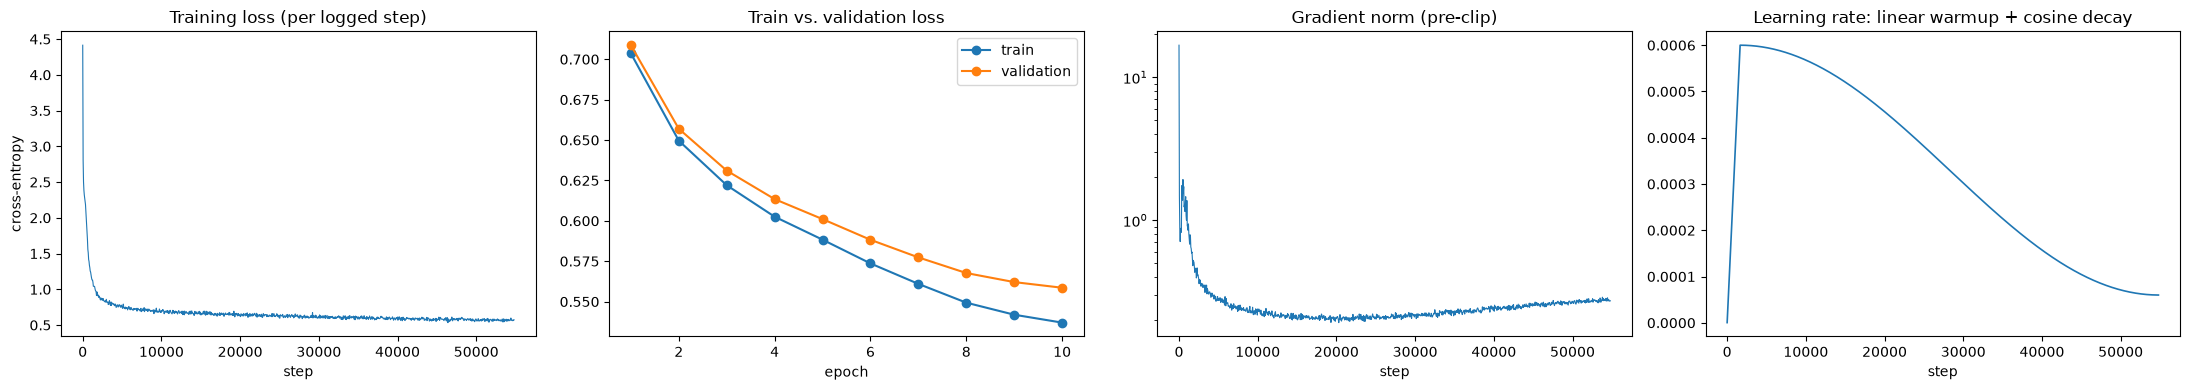

,epoch,step,lr,train_loss,val_loss,gen_gap,val_ppl,val_bpc,train_top1,val_top1,wall_time_min,peak_mem_mb
0,1,5485,0.0006,0.7036,0.7087,0.0051,2.0313,1.0224,0.7767,0.7757,8.0636,3324.1489
1,2,10970,0.0006,0.6496,0.6570,0.0074,1.9289,0.9478,0.7927,0.7911,15.3997,3324.1489
2,3,16455,0.0005,0.6220,0.6311,0.0091,1.8797,0.9105,0.8012,0.7990,19.3885,3324.1489
3,4,21940,0.0004,0.6026,0.6134,0.0109,1.8468,0.8850,0.8071,0.8046,23.3802,3324.1489
4,5,27425,0.0003,0.5883,0.6011,0.0127,1.8241,0.8672,0.8114,0.8083,27.4038,3324.1489
5,6,32910,0.0003,0.5736,0.5883,0.0146,1.8009,0.8487,0.8156,0.8119,31.4134,3324.1489
6,7,38395,0.0002,0.5610,0.5774,0.0164,1.7813,0.8330,0.8197,0.8155,35.4132,3324.1489
7,8,43880,0.0001,0.5493,0.5677,0.0183,1.7642,0.8190,0.8231,0.8184,39.4383,3324.1489
8,9,49365,0.0001,0.5419,0.5621,0.0202,1.7543,0.8109,0.8254,0.8202,43.4105,3324.1489
9,10,54850,0.0001,0.5370,0.5586,0.0216,1.7482,0.8059,0.8267,0.8212,47.3667,3324.1489


In [14]:
import matplotlib.pyplot as plt
rows = read_run_logs(train_result)
steps = [r for r in rows if "train_loss" in r and "event" not in r]
print(f"Raw logs for this run ({len(train_result['log_paths'])} session(s)):", *[Path(p).name for p in train_result["log_paths"]], sep="\n  ")
ep = train_result["history"]
fig, ax = plt.subplots(1, 4, figsize=(22, 4))
ax[3].plot([r["step"] for r in steps], [r["lr"] for r in steps], lw=1.2)
ax[3].set_title("Learning rate: linear warmup + cosine decay"); ax[3].set_xlabel("step")
ax[0].plot([r["step"] for r in steps], [r["train_loss"] for r in steps], lw=0.8)
ax[0].set_title("Training loss (per logged step)"); ax[0].set_xlabel("step"); ax[0].set_ylabel("cross-entropy")
ax[1].plot([r["epoch"] + 1 for r in ep], [r["train_loss"] for r in ep], "o-", label="train")
ax[1].plot([r["epoch"] + 1 for r in ep], [r["val_loss"] for r in ep], "o-", label="validation")
ax[1].set_title("Train vs. validation loss"); ax[1].set_xlabel("epoch"); ax[1].legend()
ax[2].plot([r["step"] for r in steps], [r["grad_norm"] for r in steps], lw=0.8)
ax[2].set_yscale("log"); ax[2].set_title("Gradient norm (pre-clip)"); ax[2].set_xlabel("step")
plt.tight_layout(); plt.savefig(OUT_DIR / "loss_curves.png", dpi=150); plt.show()

EPOCH_TBL = pd.DataFrame(train_result["history"])
EPOCH_TBL["epoch"] += 1
EPOCH_TBL["gen_gap"] = EPOCH_TBL.val_loss - EPOCH_TBL.train_loss
EPOCH_TBL["val_ppl"] = np.exp(EPOCH_TBL.val_loss)
EPOCH_TBL["val_bpc"] = EPOCH_TBL.val_loss / math.log(2)
EPOCH_TBL = EPOCH_TBL[["epoch", "step", "lr", "train_loss", "val_loss", "gen_gap", "val_ppl", "val_bpc", "train_top1", "val_top1", "wall_time_min", "peak_mem_mb"]]
EPOCH_TBL.to_csv(OUT_DIR / "epoch_history.csv", index=False)
display(EPOCH_TBL.round(4))

### Interpretation — training (fill in after the run)
- **Convergence:** val loss went from [epoch 1] to [best] (BPC [x]); curve still falling at epoch 10 or plateaued?
- **Generalization gap:** [final gap] — near zero means little overfitting (100K stories, one pass per epoch); a growing gap means more dropout or fewer epochs would help.
- **Warmup + schedule:** LR panel shows the linear ramp over the first [x] steps, then cosine decay to 10%; the loss drop is smooth early (no blow-up), which is what warmup is for.
- **Stability:** [n] NaNs, [n] loss spikes, max grad norm [x] (clip = 1.0).

## 4. Text generation (1.3)

In [15]:
@torch.no_grad()
def generate(model, idx, max_new_tokens, temperature=1.0, top_k=None):
    """temperature == 0 -> greedy decoding; otherwise temperature (and optional top-k) sampling."""
    for _ in range(max_new_tokens):
        logits, _ = model(idx[:, -model.block_size:])
        logits = logits[:, -1, :].float()
        if temperature == 0:
            nxt = logits.argmax(-1, keepdim=True)
        else:
            logits = logits / temperature
            if top_k:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float("-inf")
            nxt = torch.multinomial(F.softmax(logits, -1), 1)
        idx = torch.cat([idx, nxt], dim=1)
    return idx

best = load_checkpoint(CKPT_DIR / "best.pt", DEVICE)
model.load_state_dict(best["model"]); model.eval()
set_seed(SEED)
generations, gen_tok, gen_time = [], 0, 0.0
for temp in (0.0, CFG["gen_temperature"]):
    for p in CFG["gen_prompts"]:
        ctx = torch.tensor([encode(p, char_to_idx)], device=DEVICE)
        t0 = time.time()
        out = generate(model, ctx, CFG["gen_max_new"], temp, CFG["gen_top_k"])
        if DEVICE.type == "cuda": torch.cuda.synchronize()
        gen_time += time.time() - t0; gen_tok += CFG["gen_max_new"]
        full = decode(out[0].tolist(), idx_to_char)
        generations.append({"decoding": "greedy" if temp == 0 else f"T={temp}", "prompt": p,
                            "continuation": full[len(p):], "text": full})
GEN_TOK_PER_SEC = gen_tok / gen_time

# Extra sampled continuations for the diversity metrics (batched per prompt)
div_samples = []
for p in CFG["div_prompts"]:
    ctx = torch.tensor([encode(p, char_to_idx)] * CFG["div_samples_per_prompt"], device=DEVICE)
    out = generate(model, ctx, CFG["gen_max_new"], CFG["gen_temperature"], CFG["gen_top_k"])
    div_samples += [decode(o[len(p):].tolist(), idx_to_char) for o in out]
with open(OUT_DIR / "diversity_samples.json", "w") as f:
    json.dump(div_samples, f, indent=2, ensure_ascii=False)
with open(OUT_DIR / "generations.json", "w") as f:
    json.dump(generations, f, indent=2, ensure_ascii=False)
for g_ in generations[:2] + generations[len(CFG["gen_prompts"]):len(CFG["gen_prompts"]) + 2]:
    print(f"--- {g_['decoding']} ---\n{g_['text']}\n")
print(f"generation: {GEN_TOK_PER_SEC:,.1f} tokens/sec")

--- greedy ---
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big box in the garden. She wanted to open it, but it was too hard. She asked her mommy if she could open it, but her mommy said no.

Lily was sad because she couldn't open the box. She asked her mommy

--- greedy ---
The little dog was so happy to have a new friend. They played together all day long. The end.

Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big box in the garden. She wanted to open it, but it was too heavy. She asked her mommy if she could op

--- T=0.8 ---
Once upon a time, there was a big truck. The truck had many lots of firemen. The truck was big and had a lot of water. The truck driver was very naughty. He said he did not take medicine. 

One day, the truck got too hurt, and it was very scared. It needed a bath. The truck driver took the bath and started to cry. 

--- 

## 5. Metrics → `metrics_report.csv`
Distinct-n and the repeated 4-gram rate use **word** n-grams on continuations only (prompt excluded), over all sampled T=0.8 outputs (showcase + 40 diversity samples). Greedy-decoding values are reported separately because greedy decoding is deterministic and prone to loops.

In [16]:
def _ngrams(tokens, n):
    return [tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]

def distinct_n(texts, n):
    grams = [g for t in texts for g in _ngrams(t.split(), n)]
    return len(set(grams)) / max(1, len(grams))

def repeated_ngram_rate(texts, n=4):
    rates = []
    for t in texts:
        g = _ngrams(t.split(), n)
        if g:
            rates.append((len(g) - len(set(g))) / len(g))
    return float(np.mean(rates)) if rates else 0.0

step_rows = [r for r in read_run_logs(train_result) if "grad_norm" in r and "event" not in r]
bi = train_result["best_epoch"]; best_rec = train_result["history"][bi]
sampled = [g_["continuation"] for g_ in generations if g_["decoding"] != "greedy"] + div_samples
greedy  = [g_["continuation"] for g_ in generations if g_["decoding"] == "greedy"]
hw = hardware_info(DEVICE)
metrics = {
    "member": MEMBER, "run_name": CFG["run_name"], "seed": SEED, "best_epoch": bi + 1, "epochs_trained": len(train_result["history"]),
    "arch": f"GPT {CFG['n_layer']}L-{CFG['n_head']}H-{CFG['n_embd']}d ctx{CFG['block_size']} preLN tied={CFG['tie_weights']}",
    "train_ce": best_rec["train_loss"], "val_ce": best_rec["val_loss"],
    "perplexity": math.exp(best_rec["val_loss"]), "bits_per_char": best_rec["val_loss"] / math.log(2),
    "generalization_gap": best_rec["val_loss"] - best_rec["train_loss"],
    "top1_next_char_acc_val": best_rec["val_top1"],
    "distinct_1": distinct_n(sampled, 1), "distinct_2": distinct_n(sampled, 2), "distinct_3": distinct_n(sampled, 3),
    "repeated_4gram_rate": repeated_ngram_rate(sampled, 4),
    "greedy_distinct_2": distinct_n(greedy, 2), "greedy_repeated_4gram_rate": repeated_ngram_rate(greedy, 4),
    "nan_count": train_result["nan_count"], "loss_spikes": train_result["loss_spikes"],
    "max_grad_norm": max(r["grad_norm"] for r in step_rows), "mean_grad_norm": float(np.mean([r["grad_norm"] for r in step_rows])),
    "grad_clip": CFG["grad_clip"],
    "param_count": N_PARAMS,
    "train_tokens_per_sec": train_result["mean_tok_per_sec"], "gen_tokens_per_sec": GEN_TOK_PER_SEC,
    "peak_memory_mb": train_result["peak_mem_mb"], "total_train_time_min": train_result["total_time_s"] / 60,
    "total_wall_time_min": train_result["wall_time_s"] / 60,
    "gpu": hw.get("gpu", "none"), "cpu": f'{hw["cpu"]} ({hw["cpu_count"]} cores)', "vocab_size": VOCAB_SIZE,
    "n_diversity_samples": len(sampled), "n_train_stories": len(train_texts), "n_val_stories": len(val_texts),
    "checkpoint": "checkpoints/best.pt", "raw_log": "; ".join(Path(p).name for p in train_result["log_paths"]),
}
write_metrics_csv([metrics], MEMBER_DIR / "metrics_report.csv")
write_manifest(CFG, DEVICE, {"checkpoint_to_result": {"checkpoints/best.pt": f"best epoch {bi + 1} (weights only): metrics_report.csv, outputs/generations.json, outputs/diversity_samples.json",
                                                       "checkpoints/last.pt": "final epoch + optimizer state (resume point)"},
                             "n_params": N_PARAMS, "raw_logs": train_result["log_paths"]})
groups = {
    "Loss / likelihood": ["train_ce", "val_ce", "generalization_gap", "perplexity", "bits_per_char", "top1_next_char_acc_val"],
    "Generation diversity (sampled T=0.8)": ["distinct_1", "distinct_2", "distinct_3", "repeated_4gram_rate", "n_diversity_samples"],
    "Greedy decoding": ["greedy_distinct_2", "greedy_repeated_4gram_rate"],
    "Training stability": ["nan_count", "loss_spikes", "max_grad_norm", "mean_grad_norm", "grad_clip"],
    "Cost / efficiency": ["param_count", "train_tokens_per_sec", "gen_tokens_per_sec", "peak_memory_mb", "total_train_time_min", "total_wall_time_min"],
    "Hardware / provenance": ["gpu", "cpu", "best_epoch", "epochs_trained", "arch", "checkpoint", "raw_log"],
}
for g, keys in groups.items():
    print(f"\n── {g} ──")
    display(pd.Series({k: metrics[k] for k in keys}, name="value").to_frame())

Metrics -> <REPO>\task1_llm\tejas\metrics_report.csv


Manifest -> <REPO>\reproducibility\manifests\task1_llm\tejas\manifest_t1_gpt_tejas.json

── Loss / likelihood ──


,value
train_ce,0.537003
val_ce,0.558591
generalization_gap,0.021588
perplexity,1.748208
bits_per_char,0.805877
top1_next_char_acc_val,0.821218



── Generation diversity (sampled T=0.8) ──


,value
distinct_1,0.272694
distinct_2,0.693433
distinct_3,0.890076
repeated_4gram_rate,0.003563
n_diversity_samples,45.000000


...

,value
nan_count,18.000000
loss_spikes,0.000000
max_grad_norm,16.766830
mean_grad_norm,0.279816
grad_clip,1.000000



── Cost / efficiency ──


,value
param_count,1.077542e+07
train_tokens_per_sec,3.576457e+05
gen_tokens_per_sec,2.566728e+02
peak_memory_mb,3.324149e+03
total_train_time_min,4.535579e+01
total_wall_time_min,4.736674e+01



── Hardware / provenance ──


,value
gpu,NVIDIA GeForce RTX 4090
cpu,AMD Ryzen 9 7950X 16-Core Processor (32 cores)
best_epoch,10
epochs_trained,10
arch,GPT 6L-6H-384d ctx256 preLN tied=True
checkpoint,checkpoints/best.pt
raw_log,t1_gpt_tejas_20261001-144225.jsonl


### Interpretation — metrics (fill in after the run)
- **Perplexity [x] / BPC [x]:** the model is on average as uncertain as choosing among [x] characters; [x] bits per character vs. log2(V) = [x] bits for a uniform guess.
- **Top-1 accuracy [x]:** most errors are at word starts, where many continuations are valid; mid-word characters are near-deterministic.
- **Diversity:** sampled Distinct-2 [x] vs. greedy [x], repeated 4-gram rate [x] vs. [x] — greedy decoding loops, temperature sampling trades a little coherence for diversity.
- **Cost:** [params] parameters, [x] tokens/s training, [x] tokens/s generation (no KV cache, so every new character re-runs the full context), peak memory [x] MB.

## 6. Failure-analysis candidates (1.4)
An automatic scan of the generations to help you pick three cases. Write the analysis itself in `failure_analysis.md`: the snippet, the failure type (repetition, broken grammar, loss of coherence, hallucination or character drift), and why it happens.

In [17]:
known_words = set(" ".join(train_texts[:5000]).lower().split())
cands = []
for g_ in generations:
    c = g_["continuation"]
    words = c.split()
    rep = repeated_ngram_rate([c], 4)
    nonwords = [w for w in words if w.isalpha() and w.lower() not in known_words]
    cands.append({"decoding": g_["decoding"], "prompt": g_["prompt"], "repeated_4gram_rate": round(rep, 3),
                  "possible_nonwords": nonwords[:8], "snippet": c[:220]})
cands.sort(key=lambda r: (-r["repeated_4gram_rate"], -len(r["possible_nonwords"])))
with open(OUT_DIR / "failure_candidates.json", "w") as f:
    json.dump(cands, f, indent=2, ensure_ascii=False)
for r in cands[:6]:
    print(json.dumps(r, ensure_ascii=False, indent=1))

{
 "decoding": "greedy",
 "prompt": "One day, Tom",
 "repeated_4gram_rate": 0.213,
 "possible_nonwords": [
  "cl"
 ],
 "snippet": " wanted to play with his toys and run around outside. He saw a big tree with many leaves. Tom wanted to climb the tree, but he was too small. He tried to climb the tree, but he could not. Tom was sad.\n\nTom saw a big tree"
}
{
 "decoding": "greedy",
 "prompt": "Lily was sad because",
 "repeated_4gram_rate": 0.172,
 "possible_nonwords": [
  "ang"
 ],
 "snippet": " she loved her mommy and daddy. She wanted to help her mommy and daddy. She asked her mommy if she could help her mommy and daddy. Her mommy and daddy said yes, but they had to be careful and not touch the books. They sa"
}
{
 "decoding": "greedy",
 "prompt": "Once upon a time",
 "repeated_4gram_rate": 0.017,
 "possible_nonwords": [],
 "snippet": ", there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big box in the garden. She wanted to open it, but it 

## 7. Export all Task 1 artifacts as one zip (laid out like the repo)
Unzip at the **repo root** (`unzip task1_tejas_export.zip` inside `Data266_Lab/`); it merges into `task1_llm/tejas/` and `reproducibility/`. `data_processed/` is excluded (regenerable and too large for GitHub). `best.pt` is weights-only (commit it). `last.pt` also holds optimizer state for resuming (~3× larger); if it's over 95 MB it's flagged, so keep it on Drive and link it in the README instead of committing it.

In [18]:
import shutil, zipfile
import tempfile
STAGE = Path(tempfile.gettempdir()) / "task1_export"; shutil.rmtree(STAGE, ignore_errors=True)
rel_member = MEMBER_DIR.relative_to(REPO_ROOT)
for sub in ("checkpoints", "outputs"):
    shutil.copytree(MEMBER_DIR / sub, STAGE / rel_member / sub)
shutil.copy2(MEMBER_DIR / "metrics_report.csv", STAGE / rel_member / "metrics_report.csv")
for src_dir in (LOG_DIR, MANI_DIR):
    dst = STAGE / Path(src_dir).relative_to(REPO_ROOT); dst.mkdir(parents=True, exist_ok=True)
    for f in Path(src_dir).glob("*"):
        shutil.copy2(f, dst)
ZIP = REPO_ROOT.parent / "task1_tejas_export.zip"     # outside the repo so it never gets committed
with zipfile.ZipFile(ZIP, "w", zipfile.ZIP_DEFLATED) as z:
    for f in sorted(STAGE.rglob("*")):
        if f.is_file():
            z.write(f, f.relative_to(STAGE))
names = zipfile.ZipFile(ZIP).namelist()
print(f"{len(names)} files, {ZIP.stat().st_size/1e6:.1f} MB -> {ZIP}")
for f in sorted(STAGE.rglob("*.pt")):
    mb = f.stat().st_size / 1e6
    print(f"  {f.relative_to(STAGE)}: {mb:.1f} MB" + ("  ⚠️ >95 MB: keep on Drive, don't commit" if mb > 95 else ""))
try:
    from google.colab import files; files.download(str(ZIP))
except ImportError:
    pass

11 files, 159.4 MB -> <HOME>\Desktop\task1_tejas_export.zip
  task1_llm\tejas\checkpoints\best.pt: 44.7 MB
  task1_llm\tejas\checkpoints\last.pt: 131.5 MB  ⚠️ >95 MB: keep on Drive, don't commit
